In [1]:
import torch
import patcher
import os
from matplotlib import pyplot as plt

context = patcher.Context('../db', 1)

os.makedirs('../images/database_test', exist_ok=True)

def draw(request, filename, method='load', rng=None):
    x = patcher.load(context, [request]) if method == 'load' else patcher.load_climate(context, [request])
    x = x[0]
    x = x[tuple([-1] * (x.dim() - 2) + [slice(None), slice(None)])]
    plt.figure(figsize=(6, 4))
    if method == 'load':
        if rng == 'auto':
            plt.pcolormesh(x)
        elif 'lsm' in filename:
            plt.pcolormesh(x, vmin=0, vmax=1)
        else:
            plt.pcolormesh(x, vmin=-15, vmax=15)
    else:
        plt.pcolormesh(x)
    plt.colorbar()
    plt.savefig(f'../images/database_test/{filename}.png')
    plt.close()

In [2]:
x = patcher.load(context, [patcher.Request('inm_t2m', 0, 4, '20200502', 16, 16, 7, 4, 4, 2)])[0]
x[0, :, 0, 0]

tensor([0.5000, 0.8500, 0.6000, 0.8000,    nan,    nan,    nan])

In [13]:
x = patcher.load(context, [patcher.Request('inm_t2m', 0, 4, '20000502', 1, 1, 7, 1, 4, 2)])[0]
print(x[0, :, 0, 0])
y = patcher.load(context, [patcher.Request('inm_t2m', 0, 4, '20000502', 1, 1, 28, 1, 1, 2)])[0]
print(y[0, :, 0, 0])
print(torch.mean(y[0, :4, 0, 0]))
print(torch.mean(y[0, 4:8, 0, 0]))
print(torch.mean(y[0, 8:12, 0, 0]))
print(torch.mean(y[0, 12:16, 0, 0]))
print(torch.mean(y[0, 16:20, 0, 0]))

tensor([-0.3125, -0.4750, -0.5125, -0.6500, -0.5875, -0.3250, -0.1375])
tensor([-0.2500, -0.4500, -0.2500, -0.3000, -0.3000, -0.6500, -0.5500, -0.4000,
        -0.4500, -0.5000, -0.5500, -0.5500, -0.5500, -0.6000, -0.7000, -0.7500,
        -0.5000, -0.6000, -0.7000, -0.5500, -0.4000, -0.3500, -0.3000, -0.2500,
        -0.2000, -0.2500, -0.1000,  0.0000])
tensor(-0.3125)
tensor(-0.4750)
tensor(-0.5125)
tensor(-0.6500)
tensor(-0.5875)


In [2]:
draw(patcher.Request('t2m', 0, 0, '19800101', 1440, 361, 1, 1, 1), 'era')
draw(patcher.Request('t2m', 0, 0, '19800101', 1440 // 4, 361 // 4 + 1, 1, 4, 1), 'era_1regional')
draw(patcher.Request('t2m', 0, 0, '19800101', 1440 // 16, 361 // 16 + 1, 1, 16, 1), 'era_2global')
draw(patcher.Request('t2m', 720, 0, '19800101', 1440, 361, 1, 1, 1), 'era_shifted_lon')
draw(patcher.Request('t2m', 0, 90, '19800101', 1440, 361, 1, 1, 1), 'era_shifted_lat')
draw(patcher.Request('t2m', 0, -90, '19800101', 1440, 361, 1, 1, 1), 'era_shifted_lat_negative')
draw(patcher.Request('t2m', -70, 200, '19800101', 507, 99, 1, 1, 1), 'era_cropped')
draw(patcher.Request('t2m', 0, 0, '20260430', 1440, 361, 1, 1, 1), 'era_last')
draw(patcher.Request('t2m', 0, 0, '20260401', 1440, 361, 30, 1, 1), 'era_last_time_size')
draw(patcher.Request('t2m', 0, 0, '19800101', 1440, 361, 1, 1, 30), 'era_aggregated')
draw(patcher.Request('t2m', 0, 0, '19910101', 1440, 361, 1, 1, 365*30 + 8), 'era_aggregated_large') # Должен быть 0 или очень близко
draw(patcher.Request('t2m', 0, 0, '19800101', 1440, 361, 1, 1, 1), 'era_climate', 'load_climate')
draw(patcher.Request('t2m', 0, 0, '19800101', 1440 // 4, 361 // 4 + 1, 1, 4, 1), 'era_climate_1regional', 'load_climate')
draw(patcher.Request('t2m', 0, 0, '19800101', 1440 // 16, 361 // 16 + 1, 1, 16, 1), 'era_climate_2global', 'load_climate')
draw(patcher.Request('t2m', 0, 0, '19800101', 1440, 361, 1, 1, 30), 'era_aggregate_climate', 'load_climate')

draw(patcher.Request('inm_t2m', 0, 0, '19920101', 360, 91, 1, 1, 1, 1), 'forecast')
draw(patcher.Request('inm_t2m', 0, 0, '20250101', 360, 91, 1, 1, 1, 1), 'forecast_operative')
draw(patcher.Request('inm_t2m', 0, 0, '19920101', 360, 91, 1, 1, 1, 2), 'forecast_null') # Должен быть пустым
draw(patcher.Request('inm_t2m', 0, 0, '19920101', 360 // 4, 91 // 4 + 1, 1, 4, 1, 1), 'forecast_1global')
draw(patcher.Request('inm_t2m', 0, 0, '19920101', 360, 91, 1, 1, 1, 1), 'forecast_climate', 'load_climate')
draw(patcher.Request('inm_t2m', 0, 0, '19920101', 360, 91, 1, 1, 30, 1), 'forecast_aggregated')

draw(patcher.Request('lsm', 0, 0, '19800101', 1440, 361, 1, 1, 1), 'lsm')
draw(patcher.Request('lsm', 0, 0, '19800101', 1440, 361, 1, 1, 30), 'lsm_aggregated')
draw(patcher.Request('lsm', 0, 0, '19800101', 1440, 361, 1, 1, 1), 'lsm_climate', 'load_climate') # Должны быть нули

In [3]:
import sys
sys.path.append('../db')
from content import ELEMENTS

for element in ELEMENTS:
    if 'inm_' in element:
        draw(patcher.Request(element, 0, 0, '19920101', 360, 91, 1, 1, 1, 1), f'element_{element}', rng='auto')
    else:
        draw(patcher.Request(element, 0, 0, '19800101', 1440, 361, 1, 1, 1), f'element_{element}', rng='auto')

In [4]:
from database import PatchDataset
from matplotlib import pyplot as plt

ds = PatchDataset(
    input_variables=['t2m', 'lsm', 'inm_t2m', 'lat', 'lon', 'year', 'day', 'inm_lead_time', 'inm_day', 'inm_lat', 'inm_lon'],
    target_variables=['t2m', 'day', 'lat', 'lon'],
    time_range=('19910101', '20201231'),
    mask='snow',
    epoch_size=1000,
    batch_size=8,
    era_scales=[
        {'id': 'local', 'xSize': 16, 'ySize': 16, 'tSize': 7, 'xyStep': 1, 'tStep': 1},
        {'id': 'regional', 'xSize': 16, 'ySize': 16, 'tSize': 6, 'xyStep': 4, 'tStep': 7},
        {'id': 'global', 'xSize': 16, 'ySize': 16, 'tSize': 4, 'xyStep': 16, 'tStep': 30},
    ],
    inm_scales=[
        {'id': 'regional', 'xSize': 16, 'ySize': 16, 'tSize': 6, 'xyStep': 1, 'tStep': 1},
        {'id': 'global', 'xSize': 16, 'ySize': 16, 'tSize': 4, 'xyStep': 4, 'tStep': 7},
    ],
    target_scale={'xSize': 16, 'ySize': 16, 'tSize': 6, 'xyStep': 4, 'tStep': 1},
)

x, y = ds[0]

print('X')
for key in x.keys():
    print(key, x[key].shape)

print('\nY')
for key in y.keys():
    print(key, y[key].shape)

TypeError: missing a required argument: 'modes'

In [ ]:
for level in ['local', 'regional', 'global']:
    for key in ['lon', 'lat', 'year', 'day']:
        print(f'{key}_{level}', x[f'{key}_{level}'][0, ...])
print('inm_lead_time_regional', x['inm_lead_time_regional'][0, ...])
print('inm_lead_time_global', x['inm_lead_time_global'][0, ...])

print()
for match_key in ['day', 'lat', 'lon']:
    print(f'inm_{match_key}', x[f'inm_{match_key}_regional'][0, ...])
    print(f'target_{match_key}', y[match_key][0, ...]) # Должен совпадать с предыдущей строчкой

In [ ]:
def draw_red_square(data, N):
    center_y, center_x = data.shape[0] / 2, data.shape[1] / 2
    y_start = center_y - N / 2
    x_start = center_x - N / 2

    rect = plt.Rectangle((x_start, y_start), N, N, linewidth=1, edgecolor='red', facecolor='none')
    plt.gca().add_patch(rect)

# несовпадают из-за разных осреднений по времени и это нормально
plt.pcolormesh(x['t2m_local'][0, 0, :, :])
plt.savefig(f'../images/database_test/database_t2m_local.png')
plt.close()

plt.pcolormesh(x['t2m_regional'][0, 0, :, :])
plt.savefig(f'../images/database_test/database_t2m_regional.png')
plt.close()

plt.pcolormesh(x['t2m_global'][0, 0, :, :])
plt.savefig(f'../images/database_test/database_t2m_global.png')
plt.close()

plt.pcolormesh(x['lsm_local'][0, 0, :, :])
plt.savefig(f'../images/database_test/database_lsm_local.png')
plt.close()

plt.pcolormesh(x['lsm_regional'][0, 0, :, :])
draw_red_square(x['lsm_regional'][0, 0, :, :], 4)
plt.savefig(f'../images/database_test/database_lsm_regional.png')
plt.close()

plt.pcolormesh(x['lsm_global'][0, 0, :, :])
draw_red_square(x['lsm_global'][0, 0, :, :], 4)
draw_red_square(x['lsm_global'][0, 0, :, :], 1)
plt.savefig(f'../images/database_test/database_lsm_global.png')
plt.close()

plt.pcolormesh(x['inm_t2m_regional'][0, 0, 0, :, :])
plt.savefig(f'../images/database_test/database_inm_t2m_regional.png')
plt.close()

plt.pcolormesh(x['inm_t2m_global'][0, 0, 0, :, :])
plt.savefig(f'../images/database_test/database_inm_t2m_global.png')
plt.close()

In [4]:
# speed test
from tqdm.notebook import tqdm

for x in tqdm(ds.loader):
    pass

  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

tensor(0.0250)


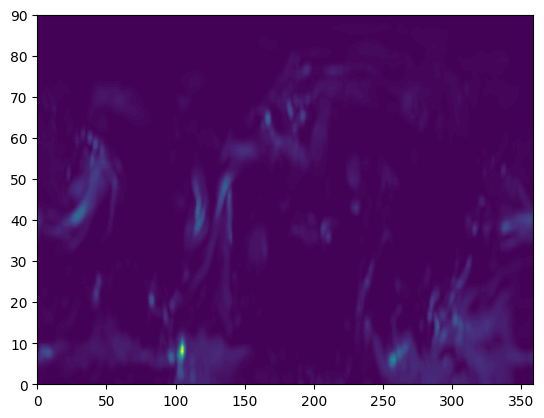

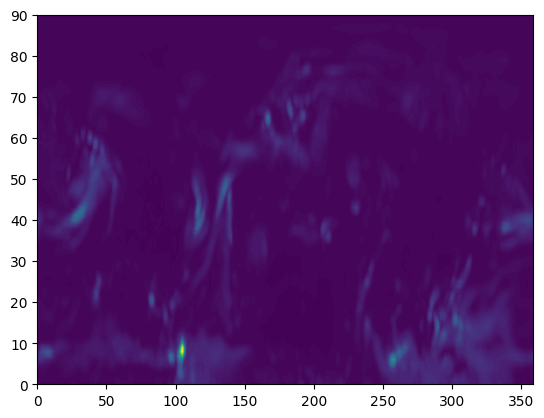

In [26]:
from matplotlib import pyplot as plt
import xarray as xr
import numpy as np

ds = xr.open_dataset('../../../PREC/north202012.nc')
data_nc = torch.from_numpy(np.roll(ds.PREC.values, 180, axis=3)[0, 0, :, :])

req = patcher.Request('inm_tp', 0, 0, '20201201', 360, 91, 1, 1, 1, 12)
data_db = patcher.load(context, [req])[0][0, 0, :, :]
data_db_climate = patcher.load_climate(context, [req])[0][0, :, :]
print(torch.max(torch.abs(data_nc - (data_db + data_db_climate))))
plt.contourf(data_nc, 101)
plt.show()
plt.contourf(data_db + data_db_climate, 101)
plt.show()